In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random


In [7]:
def fill_with_edge_color_stop(image_path=None, img=None, fill_percent=0.5, fill_stop= 1.0, fill_direction='left',rotate=True):
    # Load the image
    if img is None:
        img = cv2.imread(image_path,cv2.IMREAD_UNCHANGED)
    if rotate:
        img =  cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    img = img[:, :, 0:3]

    
    height, width = img.shape[:2]
    fill_percent = max(0.0, min(1.0, fill_percent))  # clamp 0–1

    if fill_direction == 'left':
        fill_width = int(width * fill_percent)
        fill_width_stop = int(width * fill_stop)  
        source_col = min(fill_width, width - 1)
        column = img[:, source_col:source_col + 1]
        for col in range(fill_width,fill_width_stop):
            img[:, col:col + 1] = column

    elif fill_direction == 'right':
        fill_width = int(width * fill_percent)
        fill_width_stop = int(width * fill_stop)  
        source_col = max(width - fill_width - 1, 0)
        column = img[:, source_col:source_col + 1]
        for col in range(width - fill_width, fill_width_stop):
            img[:, col:col + 1] = column

    elif fill_direction == 'up':
        fill_height = int(height * fill_percent)
        fill_height_stop = int(height * fill_stop)
        source_row = min(fill_height, height - 1)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(fill_height,fill_height_stop):
            img[row_idx:row_idx + 1, :] = row

    elif fill_direction == 'down':
        fill_height = int(height * fill_percent)
        fill_height_stop = int(height * fill_stop)
        source_row = max(height - fill_height - 1, 0)
        row = img[source_row:source_row + 1, :]
        for row_idx in range(height - fill_height, fill_height_stop):
            img[row_idx:row_idx + 1, :] = row

    else:
        raise ValueError("fill_direction must be one of: 'left', 'right', 'up', 'down'.")
    return img

In [9]:
imgs_folders = "C:\\Users\\Elirio\\Desktop\\images_results\\original\\f2"
out_folder = imgs_folders
imgs = os.listdir(imgs_folders)

C:\Users\Elirio\Desktop\images_results\original\f2\IMG_4494.MOV-0.jpg


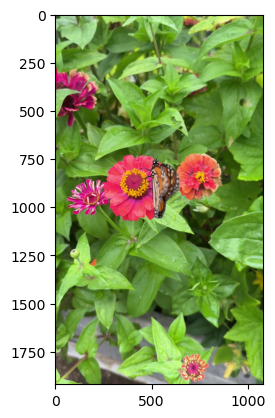

In [13]:
#imgs_folder = "imgs_plants"

#imgs_folders = "../filters-results/imgs/"
f = imgs[0]
ii = os.path.join(imgs_folders,f)
print(ii)
imgg = cv2.imread(ii)
img_rgb = cv2.cvtColor(imgg,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

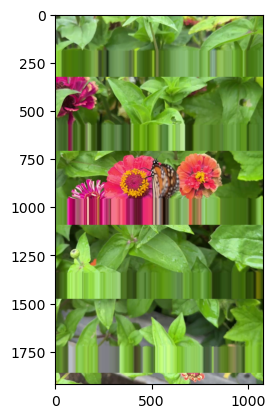

In [31]:
#fs = fill_with_edge_color_stop(image_path=ii,fill_percent=.0,fill_stop = .07, fill_direction='up',rotate=False)
fs = fill_with_edge_color_stop(image_path=ii,fill_percent=.1,fill_stop = .17, fill_direction='up',rotate=False)
fs = fill_with_edge_color_stop(img= fs,fill_percent=.3,fill_stop = .37, fill_direction='up',rotate=False)
fs = fill_with_edge_color_stop(img= fs,fill_percent=.5,fill_stop = .57, fill_direction='up',rotate=False)
fs = fill_with_edge_color_stop(img= fs,fill_percent=.7,fill_stop = .77, fill_direction='up',rotate=False)
fs = fill_with_edge_color_stop(img= fs,fill_percent=.9,fill_stop = .97, fill_direction='up',rotate=False)
fs_rgb = cv2.cvtColor(fs,cv2.COLOR_BGR2RGB)
plt.imshow(fs_rgb)


In [ ]:
fs = fill_with_edge_color_stop(ii,fill_percent=1,fill_stop = .5, fill_direction='left',rotate=False)
fs_rgb = cv2.cvtColor(fs,cv2.COLOR_BGR2RGB)
plt.imshow(fs_rgb)

In [ ]:
fs = fill_with_edge_color_stop(ii,fill_percent=.46,fill_stop = .65, fill_direction='left',rotate=True)
fs_rgb = cv2.cvtColor(fs,cv2.COLOR_BGR2RGB)
plt.imshow(fs_rgb)



In [ ]:
listf = fill_with_edge_color_step(ii,out_folder,fill_percent=.46,fill_direction='right',rotate=True)
#def fill_with_edge_color_step(image_path,out_folder, fill_percent=0.5, fill_direction='left',rotate=True):

In [ ]:
double_list = listf + listf[::-1]

In [ ]:
listf
listfile = "listbf20.txt"
with open(listfile,"w") as file:
    for o in double_list:
        file.write(f"file '{o}'\nduration 0.005\n" )
    

In [ ]:
!ffmpeg -f concat -safe 0 -i listbf20.txt -c:v libx264 -pix_fmt yuv420p -c:a aac output20.mp4

In [ ]:
!ffmpeg -f concat -safe 0 -i listbf2.txt -c:v libx264 -pix_fmt yuv420p -c:a aac output2.mp4